In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
import cmcrameri
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
import statsmodels.api as sm

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

#### Soil moisture ERA5-Land

In [4]:
# OPEN DATASET

filepath_1 = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/data_stream-moda.nc'
filepath_2 = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/SM_level2_ERA5-Land.nc'
SM_ERA5_1 = xr.open_dataset(filepath_1)
SM_ERA5_2 = xr.open_dataset(filepath_2)

SM_ERA5_1 = SM_ERA5_1.sel(valid_time=slice('1970-01-01','2025-09-01'))
SM_ERA5_1 = SM_ERA5_1.sel(valid_time=SM_ERA5_1.valid_time.dt.season=='JJA')
SM_ERA5 = xr.merge([SM_ERA5_1, SM_ERA5_2],compat='override')

In [5]:
# CREATE SOIL LEVEL FOR 20 CM

# Soil level 1: 0-7 cm
# Soil level 2: 7-28 cm
weighting_fraction = (20-7)/(28-7)
SM_ERA5['swvl_20cm'] = SM_ERA5['swvl1']+((20-7)/(28-7))*SM_ERA5['swvl2']

In [6]:
# CREATE SOIL LEVEL FOR 10 CM

# Soil level 1: 0-7 cm
# Soil level 2: 7-28 cm
weighting_fraction = (10-7)/(28-7)
SM_ERA5['swvl_10cm'] = SM_ERA5['swvl1']+weighting_fraction*SM_ERA5['swvl2']

In [7]:
# RE-INDEX

SM_ERA5 = SM_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
SM_ERA5_1970_2025 = SM_ERA5.sel(time=slice('1970-01-01','2025-09-01'))
SM_ERA5_1970_2025 = SM_ERA5_1970_2025.reindex(lat=list(reversed(SM_ERA5_1970_2025.lat)))
lons = np.array(SM_ERA5_1970_2025.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
SM_ERA5_1970_2025.coords['lon'] = lons
SM_ERA5_1970_2025 = SM_ERA5_1970_2025.sortby(SM_ERA5_1970_2025.lon)
SM_ERA5_1970_2025.to_netcdf(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

In [57]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'

SM_WM = xr.open_dataset(filepath)
SM_WM_1970_2016 = SM_WM.sel(time=slice('1970-01-01','2016-12-31'),lat=slice(59,90))
SM_WM_1970_2016_masked = SM_WM_1970_2016.where(SM_WM_1970_2016['mrsos'] < 1000)
SM_WM_1970_2016_masked = SM_WM_1970_2016_masked.drop_vars('time_bounds')
lons = np.array(SM_WM_1970_2016_masked.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
SM_WM_1970_2016_masked.coords['lon'] = lons
SM_WM_1970_2016_masked = SM_WM_1970_2016_masked.sortby(SM_WM_1970_2016_masked.lon)
SM_WM_1970_2016_masked.to_netcdf(rpath+'SM_WangMao_1970_2016_masked.nc')

In [ ]:
SM_ERA5_trends_2002_2024 = xr.open_dataset(rpath+'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024.nc')
SM_ERA5_trends_2002_2024 = SM_ERA5_trends_2002_2024.rename({'latitude':'lat', 'longitude':'lon'})
SM_ERA5_trends_2002_2024 = SM_ERA5_trends_2002_2024.reindex(lat=list(reversed(SM_ERA5_trends_2002_2024.lat)))
lons = np.array(SM_ERA5_trends_2002_2024.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
SM_ERA5_trends_2002_2024.coords['lon'] = lons
SM_ERA5_trends_2002_2024 = SM_ERA5_trends_2002_2024.sortby(SM_ERA5_trends_2002_2024.lon)
SM_ERA5_trends_2002_2024.to_netcdf(rpath+'soil_moisture_ERA5/SM_ERA5_trends_JJA_2002_2024.nc')

In [3]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

In [4]:
SM_WM = xr.open_dataset(rpath+'SM_WangMao_1970_2016_masked.nc')

In [8]:
Arctic_limit=60
lons=slice(0,300)
season='JJA'


# Compute JJA trend over land for ERA5-Land
timeslice_trend=slice(1985,2025)
ref_timeslice=slice(1970,2000)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.07 m = 70 kg/m2)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.20 m = 200 kg/m2)
SM_ERA5_converted = SM_ERA5['swvl_10cm']*100
# Regional average, Arctic excluding Greenland (lons > 300)
SM_ERA5_Arctic = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=lons))
# Select season
SM_ERA5_season = SM_ERA5_Arctic.sel(time=SM_ERA5_Arctic.time.dt.season==season)
# Annual season mean
SM_ERA5_season_annual = SM_ERA5_season.groupby(SM_ERA5_season.time.dt.year).mean('time')
# Reference period mean
SM_ERA5_ref_mean = SM_ERA5_season_annual.sel(year=ref_timeslice).mean('year')
# Create linear regression
SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_r_value, SM_ERA5_p_value, SM_ERA5_std_err = stats.linregress(SM_ERA5_season_annual.sel(year=timeslice_trend).year, (SM_ERA5_season_annual.sel(year=timeslice_trend)-SM_ERA5_ref_mean).values)

# Compute JJA trend over land for Wang & Mao dataset
# Regional average, Arctic excluding Greenland (lons > 300)
timeslice_trend=slice(1985,2016)
ref_timeslice=slice(1970,2000)
SM_WM_Arctic = functions.computeWeightedMean(SM_WM['mrsos'].sel(lon=lons))
# Select season
SM_WM_season = SM_WM_Arctic.sel(time=SM_WM_Arctic.time.dt.season==season)
# Annual season mean
SM_WM_season_annual = SM_WM_season.groupby(SM_WM_season.time.dt.year).mean('time')
# Reference period mean
SM_WM_ref_mean = SM_WM_season_annual.sel(year=ref_timeslice).mean('year')
# Create linear regression
SM_WM_slope, SM_WM_intercept, SM_WM_r_value, SM_WM_p_value, SM_WM_std_err = stats.linregress(SM_WM_season_annual.sel(year=timeslice_trend).year, (SM_WM_season_annual.sel(year=timeslice_trend)-SM_WM_ref_mean).values)


In [9]:
def xr_add_cyclic_point(da):
    """
    Inputs
    da: xr.DataArray with dimensions (time,lat,lon)
    """
    from cartopy.util import add_cyclic_point
    import xarray as xr 

    # Use add_cyclic_point to interpolate input data
    lon_idx = da.dims.index('lon')
    wrap_data, wrap_lon = add_cyclic_point(da.values, coord=da.lon, axis=lon_idx)

    # Generate output DataArray with new data but same structure as input
    outp_da = xr.DataArray(data=wrap_data, 
                           coords = {'lat': da.lat, 'lon': wrap_lon}, 
                           dims=da.dims, 
                           attrs=da.attrs)
    
    return outp_da

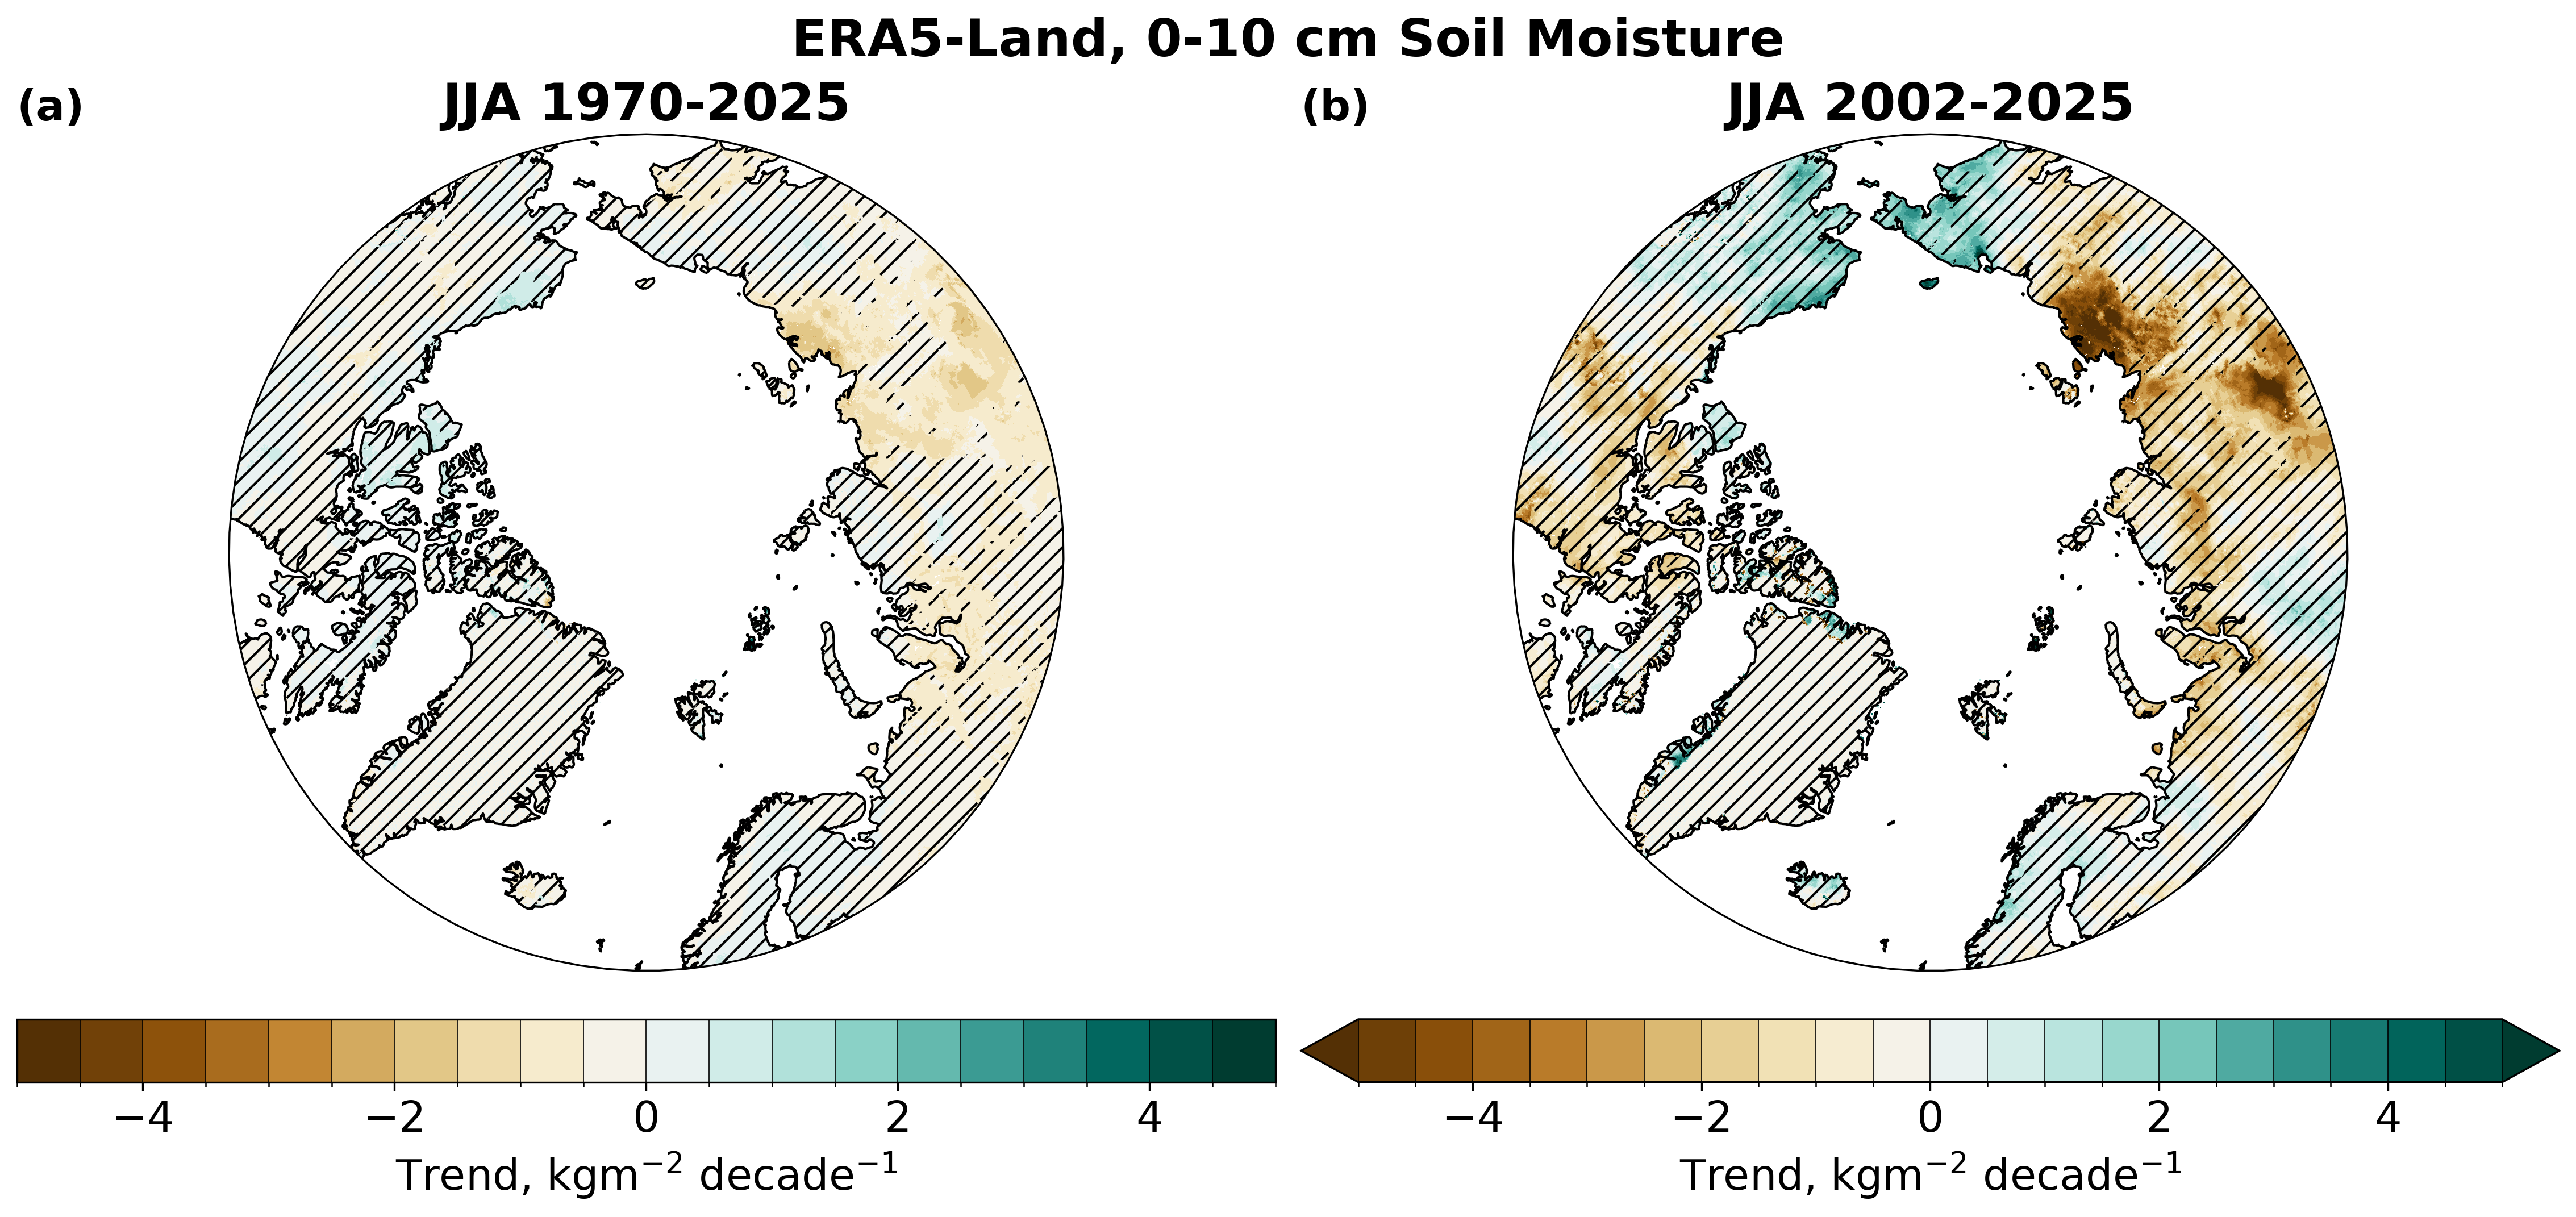

In [13]:
labels = [['(a)','(b)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 7),dpi=300, 
                              constrained_layout=True)
# Remove axis from map plots
for label in ['(a)','(b)']:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 90))

fig.suptitle('ERA5-Land, 0-10 cm Soil Moisture',fontsize=22, fontweight='bold')
# Row |: spatial trends
for ax, title, unit, file, limit in zip([ax1, ax2], 
                                  ['JJA 1970-2025', 'JJA 2002-2025'],
                                  ['kgm$^{-2}$ decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['SM_ERA5_trends_JJA_1970_2025.nc', 'SM_ERA5_trends_JJA_2002_2025.nc'], 
                                  [5, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    data = ds['trend'].T*10 # multiply by 10 to get trend per decade
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch_density=3
    hatch_style='/'
    insignificant_data = xr_add_cyclic_point(ds['p_value'].T > significance_level)
    hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    


    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    #hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='Trend, '+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
#fig.tight_layout()


<>:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3158926/1510782693.py:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title('Land excluding Greenland, latitude > 60$^{\circ}$N', fontsize=22, fontweight='bold')


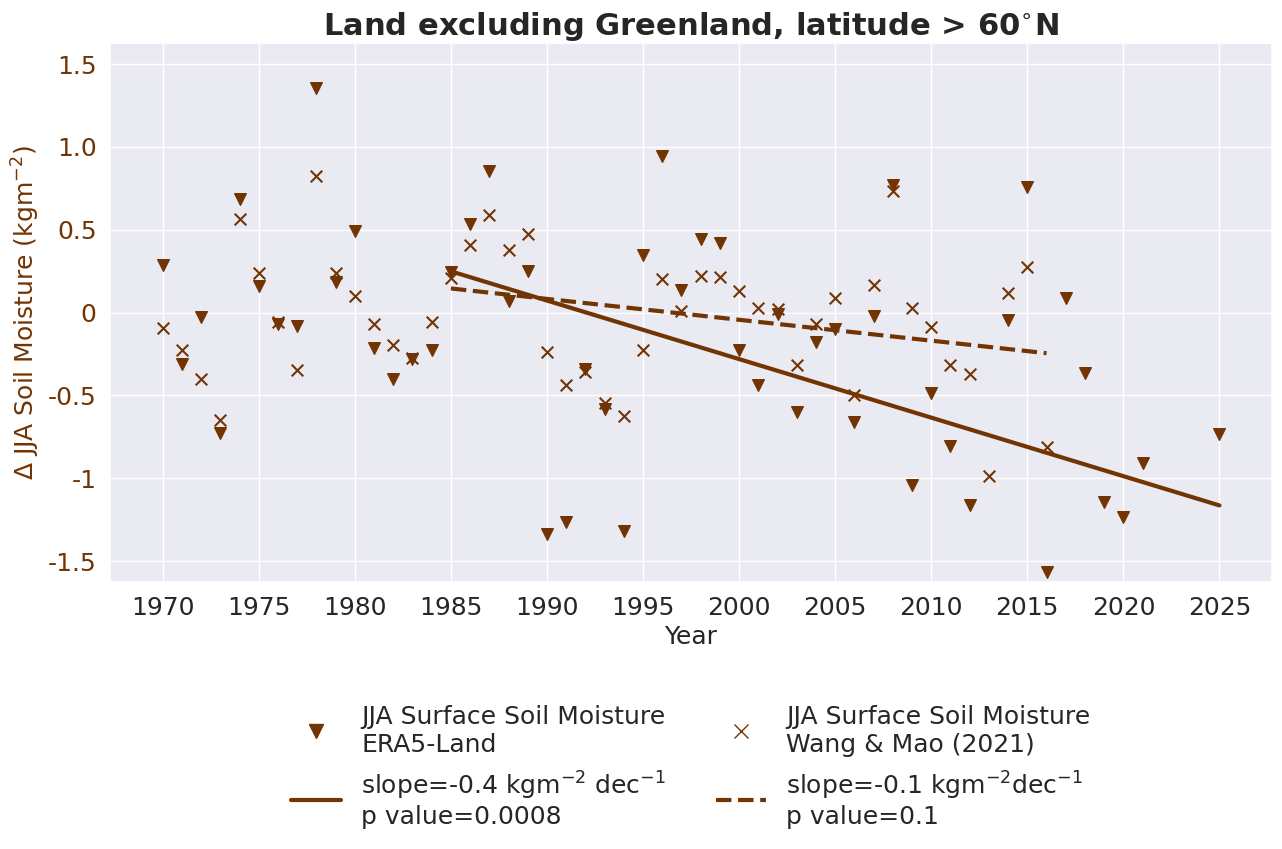

In [23]:
sns.set_theme()
# Row 2: trends
fig, ax = plt.subplots(1, 1, figsize=[15,7])

SM_color = cmcrameri.cm.glasgow.colors[70]
timeslice=slice(1970,2025)
timeslice_trend=slice(1985,2025)
for i in range(0, len(SM_ERA5_season_annual.sel(year=timeslice).year)):
    ax.scatter(SM_ERA5_season_annual.sel(year=timeslice).year[i], (SM_ERA5_season_annual.sel(year=timeslice)-SM_ERA5_ref_mean).isel(year=i), color=SM_color, marker='v',s=70)
ax.plot(SM_ERA5_season_annual.sel(year=timeslice_trend).year, SM_ERA5_intercept+SM_ERA5_slope*SM_ERA5_season_annual.sel(year=timeslice_trend).year, color=SM_color, lw=3)

timeslice=slice(1970,2016)
timeslice_trend=slice(1985,2016)
for i in range(0, len(SM_WM_season_annual.sel(year=timeslice).year)):
    ax.scatter(SM_WM_season_annual.sel(year=timeslice).year[i], (SM_WM_season_annual.sel(year=timeslice)-SM_WM_ref_mean).isel(year=i), color=SM_color, marker='x', s=70)
ax.plot(SM_WM_season_annual.sel(year=timeslice_trend).year, SM_WM_intercept+SM_WM_slope*SM_WM_season_annual.sel(year=timeslice_trend).year, color=SM_color, ls='--',lw=3)


legend_elements = [Line2D([0], [0], marker='v',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nERA5-Land'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='-', label='slope='+str(np.round(SM_ERA5_slope*10,1))+' kgm$^{-2}$ dec$^{-1}$\np value='+str(np.round(SM_ERA5_p_value,4))),
                   Line2D([0], [0], marker='x',color='None',mec=SM_color,mfc=SM_color, markersize=10, label='JJA Surface Soil Moisture\nWang & Mao (2021)'),
                   Line2D([0], [0], color=SM_color, lw=3, linestyle='--', label='slope='+str(np.round(SM_WM_slope*10,1))+' kgm$^{-2} $dec$^{-1}$\np value='+str(np.round(SM_WM_p_value,2))),]

#plt.grid()
#ax.set_title('Latitudes > 60$^{\circ}$N', fontsize=22, fontweight='bold')
years = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
#years = [2000, 2005, 2010, 2015, 2020, 2025]

ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=18)
ax.set_title('Land excluding Greenland, latitude > 60$^{\circ}$N', fontsize=22, fontweight='bold')


ax.set_xlabel('Year',fontsize=18)
ax.set_ylabel(r'$\Delta$ JJA Soil Moisture (kgm$^{-2}$)',fontsize=18)
ax.yaxis.label.set_color(SM_color)
ax.tick_params(axis='y', colors=SM_color)
ax.set_ylim([-1.625, 1.625])
yticks = [-1.5, -1, -0.5, 0, 0.5,1.0,1.5]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize=18)

ax.legend(handles=legend_elements, ncols=2, loc='lower center', 
    bbox_to_anchor=(0.5, -0.5),frameon=False, fontsize=18)
#ax.legend(handles=legend_elements, ncols=2, loc='lower center', frameon=False, fontsize=18)

In [ ]:
# Select season
timeslice_trend=slice('1970-01-01','2025-12-01')
SM_ERA5_slice = SM_ERA5.sel(time=timeslice_trend)
season='JJA'

# Annual season mean
ds_season = SM_ERA5_slice['swvl_10cm'].sel(time=SM_ERA5_slice.time.dt.season==season)
ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

x = ds_annual.year.values
X = sm.add_constant(x)

trends = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
p_values = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
for ilon in range(len(SM_ERA5_slice.lon)):
    for ilat in range(len(SM_ERA5_slice.lat)):
        y = ds_annual.isel(lon=ilon, lat=ilat).values*100 # convert to kg/m2
        model = sm.WLS(y, X)
        fit = model.fit()

        trends[ilon, ilat] = fit.params[1]
        p_values[ilon, ilat] = fit.pvalues[1]

ds_annual['trend'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, trends)
ds_annual['p_value'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, p_values)

ds_annual.to_netcdf(rpath+"SM_ERA5_trends_"+season+"_1970_2025.nc")

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual['swvl_10cm']*100 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2025.nc")

In [70]:
var = 'swvl1'
ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_20cm_trends_"+season+".nc")


In [75]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(2002,2024)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(2002,2024)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2024.nc")


In [25]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
var='swvl1'

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(1970,2016)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(1970,2016)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_1970_2016.nc")


In [4]:
season="JJA"
rpath = "/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
ds_annual = xr.open_dataset(rpath+"SM_ERA5_trends_"+season+".nc")
ds_annual = ds_annual.reindex(latitude=list(reversed(ds_annual.latitude)))

In [36]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'
ds_SM_WM = xr.open_dataset(filepath)

In [37]:
ds_SM_WM

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 564, nb: 2, lat: 360, lon: 720)
Coordinates:
  * time         (time) object 5kB 1970-01-16 12:00:00 ... 2016-12-16 12:00:00
  * lat          (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon          (lon) float64 6kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Dimensions without coordinates: nb
Data variables:
    time_bounds  (time, nb) object 9kB ...
    mrsos        (time, lat, lon) float64 1GB ...
Attributes:
    title:         Observation-based global multilayer soil moisture products...
    version:       1
    institutions:  Oak Ridge National Laboratory
    source:        Offline land surface models, reanalysis, and satellite soi...
    history:       \n2021-09-14: downloaded https://drive.google.com/file/d/1...
    references:    \n@ARTICLE{Wang2021,\n  author = {Wang, Y. and Mao, J. and...
    comments:      \ntime_period: 1970-01 through 2016-12; temporal_resolutio...
    convention:    CF-1.8

In [11]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = ds_SM_WM.sel(time=ds_SM_WM.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

    trends = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    p_values = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    for ilat in range(len(ds_SM_WM.lat)):
        for ilon in range(len(ds_SM_WM.lon)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(ds_annual.year, ds_annual['mrsos'].isel(lat=ilat, lon=ilon))
            trends[ilat, ilon] = slope
            p_values[ilat, ilon] = p_value
    
    ds_annual['trend'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, trends)
    ds_annual['p_value'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, p_values)

    ds_annual.to_netcdf(savedir+"SM_WM_trends_"+season+".nc")

In [19]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = ds_SM_WM.sel(time=ds_SM_WM.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

    trends = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    p_values = np.ones((len(ds_SM_WM.lat),len(ds_SM_WM.lon)))*np.nan
    for ilat in range(len(ds_SM_WM.lat)):
        for ilon in range(len(ds_SM_WM.lon)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(ds_annual.year.sel(year=slice(1994,2016)), ds_annual['mrsos'].isel(lat=ilat, lon=ilon).sel(year=slice(1994,2016)))
            trends[ilat, ilon] = slope
            p_values[ilat, ilon] = p_value
    
    ds_annual['trend'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, trends)
    ds_annual['p_value'] = ({'lat':ds_SM_WM.lat, 'lon':ds_SM_WM.lon}, p_values)

    ds_annual.to_netcdf(savedir+"SM_WM_trends_"+season+"_1994_2016.nc")